# Quality Control and Annotation at 16 um Resolution

This notebook processes the Visium HD **16 um bin** data. As with the 8 um pipeline, each bin is treated directly as an analysis unit -- there is **no bin2cell nucleus segmentation / single-cell aggregation**. The workflow runs QC, normalization, dimensionality reduction and clustering, annotates cell types with CellTypist, and exports the QC'd data.

**Pipeline:** read 16 um bins -> filter + QC metrics -> flag and remove low-quality bins (MAD) -> normalize + HVG + annotate -> PCA/UMAP/Leiden -> spatial visualization -> export.

## Setup and imports
Import scanpy, CellTypist, bin2cell, and plotting / statistics helpers. `Image.MAX_IMAGE_PIXELS = None` disables PIL's decompression-bomb guard so the large whole-slide H&E image can be opened. The runtime timer starts here.

In [1]:
import os

import scanpy as sc
import celltypist
import numpy as np
import matplotlib.pyplot as plt
import bin2cell as b2c
import seaborn as sns
from scipy.stats import median_abs_deviation
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

import time

notebook_start = time.time()

/Users/siyuanzhao/anaconda3/envs/loom/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


## 1. Load raw 16 um data

- `file_path`: Visium HD `square_016um` (16 um bin) output directory
- `source_image_path`: the full-resolution H&E tissue image

`b2c.read_visium` loads the expression matrix together with the high-resolution image, and `var_names_make_unique()` resolves duplicate gene names.

In [2]:
file_path = "/Volumes/Siyuan SSD/ST/skin_TXK6Z4X_A1_lite/binned_outputs/square_016um"
source_image_path = "/Volumes/Siyuan SSD/ST/H1-TXK6Z4X-A1_SK24-001_A1-4-003.tiff"
os.makedirs("stardist", exist_ok=True)
bdata = b2c.read_visium(file_path, source_image_path = source_image_path)

bdata.var_names_make_unique()
bdata

AnnData object with n_obs × n_vars = 78516 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

### Back up raw counts

Store the unprocessed counts in `bdata.raw` with `.copy()`, so the snapshot stays independent of later in-place normalization and can be exported as true raw counts.

In [3]:
bdata.raw = bdata.copy()

## 2. Filtering and QC metrics

Drop barely-detected genes (`min_cells=3`) and low-content bins (`min_genes=100`), flag mitochondrial genes (`MT-`), and compute per-bin QC metrics (`total_counts`, `n_genes_by_counts`, `pct_counts_mt`, `pct_counts_in_top_20_genes`).

In [4]:
sc.pp.filter_genes(bdata, min_cells=3)
sc.pp.filter_cells(bdata, min_genes=100)

bdata.var["mt"] = bdata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(bdata, qc_vars=["mt"], percent_top=[20], inplace=True)

### Visualize QC metrics

Inspect the distribution of the QC metrics with violin, distribution, and scatter plots.

... storing 'feature_types' as categorical
... storing 'genome' as categorical


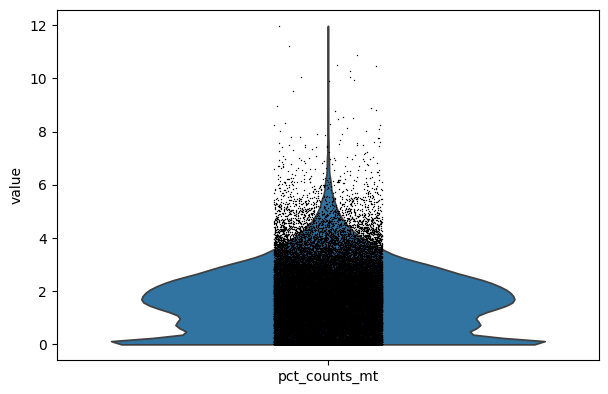

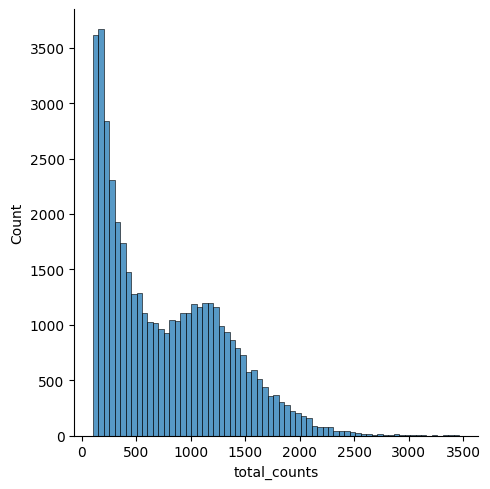

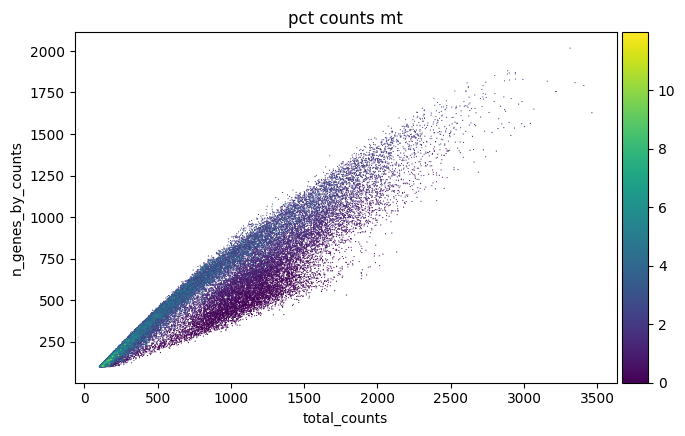

In [5]:
p1 = sc.pl.violin(bdata, "pct_counts_mt")
p2 = sns.displot(bdata.obs["total_counts"])
p3 = sc.pl.scatter(bdata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## 3. Flag low-quality bins with MAD

Use robust **median absolute deviation (MAD)** outlier detection: a metric is an outlier if it deviates from the median by more than `nmads` times the MAD.

- Count-based metrics (`log1p_total_counts`, `log1p_n_genes_by_counts`, `pct_counts_in_top_20_genes`) use **5 MADs**.
- Mitochondrial fraction `pct_counts_mt` uses **3 MADs** and additionally must be `> 8%`.

In [6]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [7]:
bdata.obs["outlier"] = (
    is_outlier(bdata, "log1p_total_counts", 5)
    | is_outlier(bdata, "log1p_n_genes_by_counts", 5)
    | is_outlier(bdata, "pct_counts_in_top_20_genes", 5)
)
bdata.obs.outlier.value_counts()

outlier
False    44417
True         2
Name: count, dtype: int64

In [8]:
bdata.obs["mt_outlier"] = is_outlier(bdata, "pct_counts_mt", 3) | (
    bdata.obs["pct_counts_mt"] > 8
)
bdata.obs.mt_outlier.value_counts()

mt_outlier
False    43047
True      1372
Name: count, dtype: int64

### Apply filtering

Remove bins flagged as `outlier` or `mt_outlier`, and print the bin count before and after filtering.

In [9]:
print(f"Total number of bins: {bdata.n_obs}")
bdata = bdata[(~bdata.obs.outlier) & (~bdata.obs.mt_outlier)].copy()
print(f"Number of bins after filtering of low quality bins: {bdata.n_obs}")

Total number of bins: 44419
Number of bins after filtering of low quality bins: 43045


### Re-inspect

Re-plot the count vs. gene scatter colored by mitochondrial fraction to confirm low-quality bins are gone.

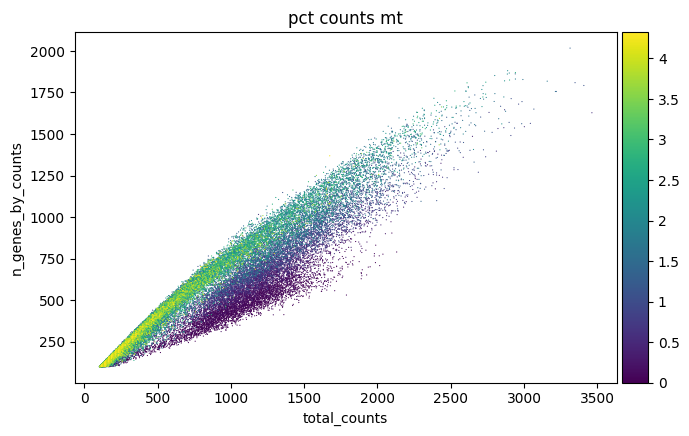

In [10]:
p1 = sc.pl.scatter(bdata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## 4. Normalization, highly variable genes, and annotation

- `normalize_total` + `log1p`: library-size normalization and log transform.
- `highly_variable_genes` (`seurat_v3`, top 5000): select highly variable genes.
- `celltypist.annotate`: predict cell types using the adult-skin reference model `Adult_Human_Skin.pkl`, writing `predicted_labels` / `conf_score`.

In [11]:
sc.pp.normalize_total(bdata,target_sum=1e4)
sc.pp.log1p(bdata)
sc.pp.highly_variable_genes(bdata,n_top_genes=5000,flavor="seurat_v3")
predictions_8bin = celltypist.annotate(bdata, model = 'Adult_Human_Skin.pkl')
bdata = predictions_8bin.to_adata()
bdata

🔬 Input data has 43045 cells and 17075 genes
🔗 Matching reference genes in the model
🧬 2945 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


AnnData object with n_obs × n_vars = 43045 × 17075
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'predicted_labels', 'conf_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'

## 5. Dimensionality reduction

Subset to highly variable genes, then `scale` -> `PCA` -> neighbor graph -> `UMAP`.

In [12]:
bdata = bdata[:, bdata.var["highly_variable"]].copy()
sc.pp.scale(bdata, max_value=10)
sc.pp.pca(bdata, use_highly_variable=True)
sc.pp.neighbors(bdata)
sc.tl.umap(bdata)

/Users/siyuanzhao/anaconda3/envs/loom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 6. Leiden clustering

Run Leiden clustering on the neighbor graph (`resolution=1`) and color the clusters on the UMAP.

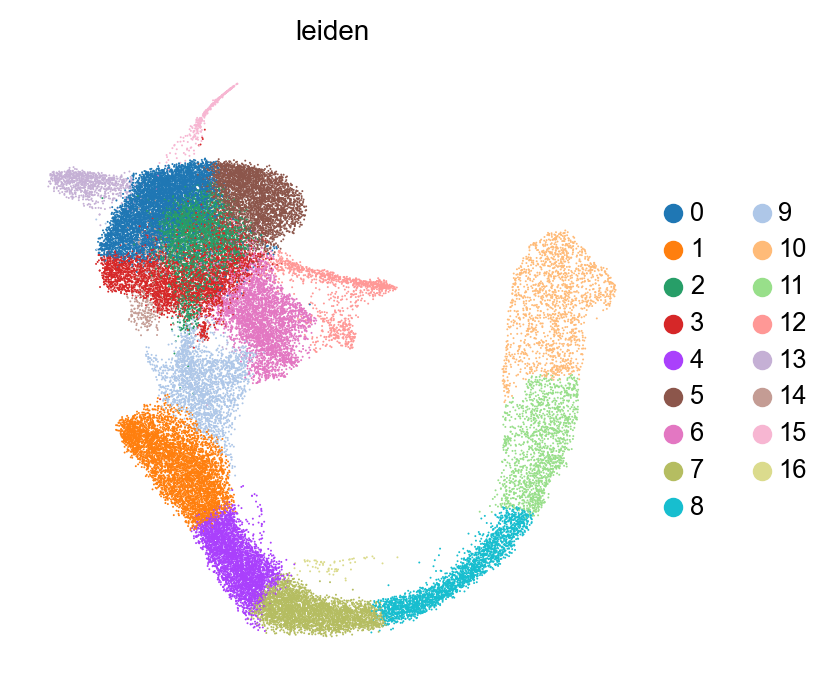

In [13]:
sc.set_figure_params(dpi=100,fontsize=10,)

sc.tl.leiden(bdata,resolution=1,key_added='leiden')
sc.pl.umap(bdata,color=['leiden'],size=2,wspace=0.25,frameon=False)

## 7. Spatial visualization

### Build the H&E background image
`b2c.scaled_he_image` resamples the full-resolution H&E to `mpp=0.5` and saves `stardist/he.tiff`, used as the background for the spatial plot below. It also writes the `spatial_cropped_150_buffer` coordinates aligned to that image.

In [14]:
b2c.scaled_he_image(bdata, mpp=0.5, save_path="stardist/he.tiff")

Cropped spatial coordinates key: spatial_cropped_150_buffer
Image key: 0.5_mpp_150_buffer


In [15]:
bdata.var["highly_variable"]

HES4       True
ISG15      True
TTLL10     True
TNFRSF4    True
SCNN1D     True
           ... 
IL9R       True
SRY        True
PCDH11Y    True
NLGN4Y     True
MT-ND5     True
Name: highly_variable, Length: 5000, dtype: bool

### Spatial expression of a gene (HES4)

Overlay each bin's `HES4` expression on the H&E background using the `spatial_cropped_150_buffer` coordinates.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


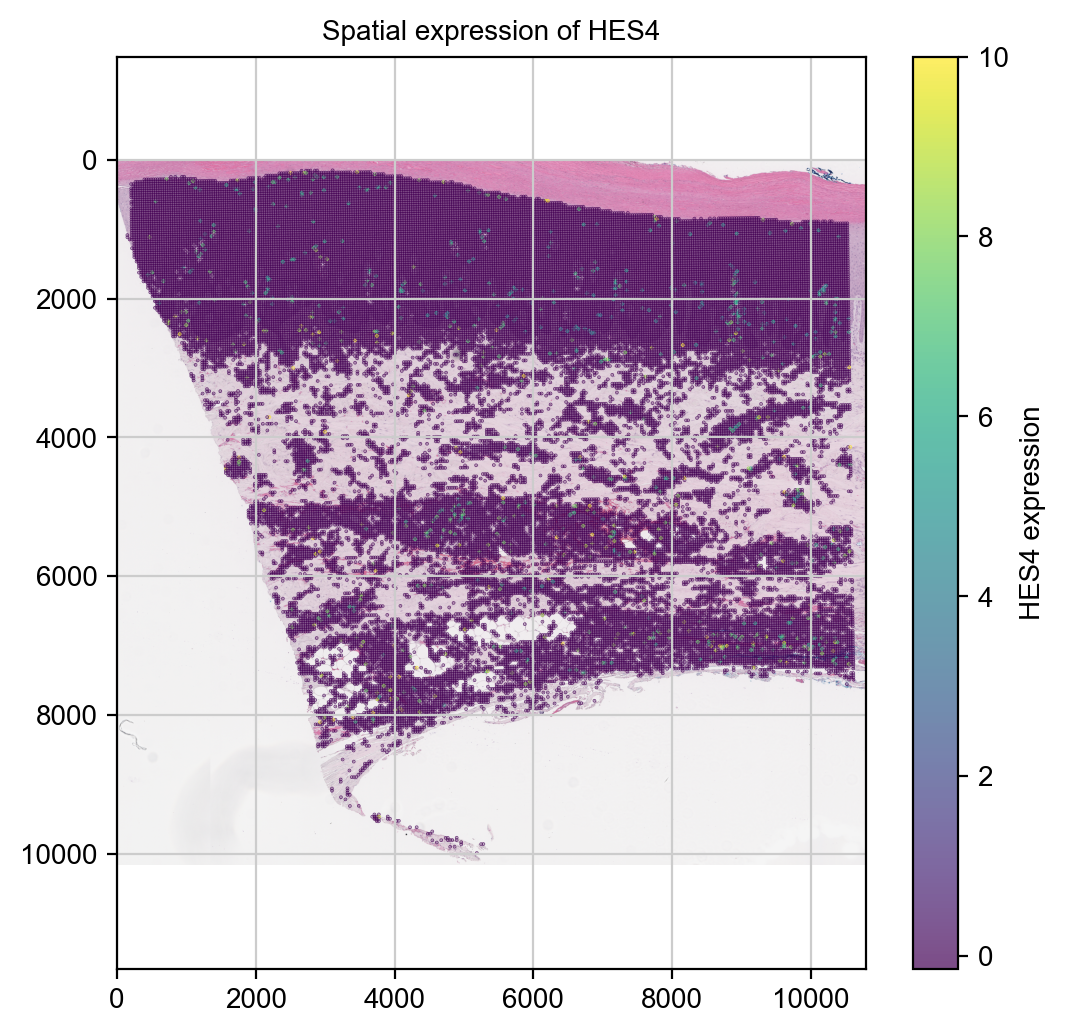

In [16]:
gene = "HES4"

bg_img = Image.open("./stardist/he.tiff")
bg_width, bg_height = bg_img.size

coords = bdata.obsm["spatial_cropped_150_buffer"]
expr = bdata[:, gene].X.toarray().flatten()

plt.figure(figsize=(6, 6))
plt.imshow(bg_img, extent=[0, bg_width, bg_height, 0])
plt.scatter(coords[:, 0], coords[:, 1], c=expr, cmap="viridis", s=0.1, alpha=0.7)
plt.colorbar(label=f"{gene} expression")
plt.title(f"Spatial expression of {gene}")
plt.axis("equal")
plt.xlim(0, bg_width)
plt.ylim(bg_height, 0) 
plt.show()


## 8. Export QC'd data

Write `bdata.raw` (raw counts of the QC'd bins) to `skin_TXK6Z4X_A1_16um_b2c_qc.h5ad` for downstream use, and print the total notebook runtime.

In [17]:
bdata.raw.to_adata().write('skin_TXK6Z4X_A1_16um_b2c_qc.h5ad')

elapsed = time.time() - notebook_start

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total notebook runtime: {hours}h {minutes}m {seconds}s")

... storing 'feature_types' as categorical
... storing 'genome' as categorical


Total notebook runtime: 0h 5m 30s
